# **Name Gender Classifier**

We selected the **Maximum Entropy** classifier for the name gender classification.  MaxEnt excels at processing highly correlated, overlapping features such as a name ending in the letter 'a' while simultaneously ending in the suffix 'na'.  Unlike Naive Bayes, which assumes all descriptive features are completely independent and double-counts overlapping evidence, the Maximum Entropy model balances these related features without overstating their combined importance by optimizing a single conditional probability distribution where all feature weights are adjusted simultaneously.  Maximum Entropy simultaneously weighs the phonetic and structural featuer to produce a calibrated, nuanced prediction.

##**Environment Setup and Data Preparation**

We retrieve the dataset and establish our randomized splits. The NLTK names corpus contains 7944 names tagged by gender.

We shuffle the data and create the exact splits: 500 for testing, 500 for development-testing (validation), and the remaining 6944 for training.

In [1]:
# Load Libraries
import nltk
import random
from nltk.corpus import names

# Download the names corpus
nltk.download('names')

# Load the data and label them
male_names = [(name, 'male') for name in names.words('male.txt')]
female_names = [(name, 'female') for name in names.words('female.txt')]

# Combine and shuffle the dataset
all_names = male_names + female_names
random.seed(42)
random.shuffle(all_names)

# Split the dataset
test_set = all_names[:500]
devtest_set = all_names[500:1000]
train_set = all_names[1000:]

print(f"Total names: {len(all_names)}")
print(f"Training set size: {len(train_set)}")
print(f"Dev-Test set size: {len(devtest_set)}")
print(f"Test set size: {len(test_set)}")

Total names: 7944
Training set size: 6944
Dev-Test set size: 500
Test set size: 500


[nltk_data] Downloading package names to /root/nltk_data...
[nltk_data]   Package names is already up-to-date!


## **Feature Extraction**

We extract the following features from the names corpus:

- Name Endings (1, 2, & 3-char): Identifies strings at the end of the name and gendered suffixes.

- Name Length & Vowel Count: Provides quantitative values for name length and syllabic density.

- Ending Vowel: Detects endings using a vowel set (including 'y')

- Consonant-Vowel Suffixes : Detects the final three characters into consonant/vowel sequences.

- Consonant Cluster Identification: Detects  consonant groupings that can signal male or surname patterns.

In [2]:
# Feature Extraction

def extract_features(name):

    name = name.lower()
    vowels = 'aeiouy'
    cv_pattern = ''.join(['v' if char in vowels else 'c' for char in name])

    features = {
        'first_letter': name[0],
        'last_letter': name[-1],
        'last_two': name[-2:] if len(name) > 1 else name,
        'last_three': name[-3:] if len(name) > 2 else name,
        'name_length': len(name),
        'vowel_count': sum(1 for char in name if char in vowels),
        'ends_in_vowel': name[-1] in vowels,
        'last_3_cv_pattern': cv_pattern[-3:] if len(cv_pattern) >= 3 else cv_pattern,
        'ends_with_consonant_cluster': cv_pattern.endswith('cc')}

    return features

# Apply the feature extraction to all sets
train_features = [(extract_features(n), gender) for (n, gender) in train_set]
devtest_features = [(extract_features(n), gender) for (n, gender) in devtest_set]
test_features = [(extract_features(n), gender) for (n, gender) in test_set]

# Display examples of the extracted features
print(f"Features for the name 'Jonathan:\n{extract_features('Jonathan')}")
print(f"Features for the name 'Christina':\n{extract_features('Christina')}")
print(f"Features for the name 'Gerard':\n{extract_features('Gerard')}")

Features for the name 'Jonathan:
{'first_letter': 'j', 'last_letter': 'n', 'last_two': 'an', 'last_three': 'han', 'name_length': 8, 'vowel_count': 3, 'ends_in_vowel': False, 'last_3_cv_pattern': 'cvc', 'ends_with_consonant_cluster': False}
Features for the name 'Christina':
{'first_letter': 'c', 'last_letter': 'a', 'last_two': 'na', 'last_three': 'ina', 'name_length': 9, 'vowel_count': 3, 'ends_in_vowel': True, 'last_3_cv_pattern': 'vcv', 'ends_with_consonant_cluster': False}
Features for the name 'Gerard':
{'first_letter': 'g', 'last_letter': 'd', 'last_two': 'rd', 'last_three': 'ard', 'name_length': 6, 'vowel_count': 2, 'ends_in_vowel': False, 'last_3_cv_pattern': 'vcc', 'ends_with_consonant_cluster': True}


## **MaxEnt Model Training**
We instantiate and train the MaxentClassifier. This implementatiion uses  the Generalized Iterative Scaling (GIS) algorithm to train the classifier. We systematically track its convergence and generalization capabilities across 100 iterations.

The results demonstrate rapid initial learning, with training accuracy steadily increasing and converging to approximately **87%** by the final iterations. However, performance on the hold-out development-test (validation) set peaks at **79.80%** after just 10 iterations before slightly degrading and plateauing near **79.00%**.

This divergence between training accuracy and  validation accuracy indicates that optimizing beyond the initial iterations causes the model to overfit the the training data rather than improving its real-world predictive power.

In [3]:
# Import Libraries
import nltk

print("Training Maximum Entropy Model and tracking evaluation metrics...")

# Define the training iteration steps)
iteration_steps = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Initialize dictionary to store metrics
training_history = {
    'iterations': iteration_steps,
    'train_acc': [],
    'dev_acc': []}

# Iteratively train and evaluate to capture scores
for iters in iteration_steps:
    current_model = nltk.MaxentClassifier.train(
        train_features,
        algorithm='GIS',
        max_iter=iters,
        trace=0 )

    # Calculate performance on both distributions
    t_acc = nltk.classify.accuracy(current_model, train_features) * 100
    d_acc = nltk.classify.accuracy(current_model, devtest_features) * 100

    # Append to our tracking history
    training_history['train_acc'].append(t_acc)
    training_history['dev_acc'].append(d_acc)

    print(f"After {iters:3d} iterations | Dev-Test Acc: {d_acc:.2f}% | Train Acc: {t_acc:.2f}%")

# Set the trained model asl the primary classifier
maxent_classifier = current_model

print("\nModel Training and Metric Tracking Complete.")

Training Maximum Entropy Model and tracking evaluation metrics...
After  10 iterations | Dev-Test Acc: 79.80% | Train Acc: 85.69%
After  20 iterations | Dev-Test Acc: 78.60% | Train Acc: 86.81%
After  30 iterations | Dev-Test Acc: 78.80% | Train Acc: 86.84%
After  40 iterations | Dev-Test Acc: 78.40% | Train Acc: 86.91%
After  50 iterations | Dev-Test Acc: 78.80% | Train Acc: 86.94%
After  60 iterations | Dev-Test Acc: 78.60% | Train Acc: 86.98%
After  70 iterations | Dev-Test Acc: 78.80% | Train Acc: 87.00%
After  80 iterations | Dev-Test Acc: 78.80% | Train Acc: 87.00%
After  90 iterations | Dev-Test Acc: 79.00% | Train Acc: 87.02%
After 100 iterations | Dev-Test Acc: 79.00% | Train Acc: 87.01%

Model Training and Metric Tracking Complete.


## **Dev-Test Evaluation Analysis**

Evaluating the trained model on the development-test set establishes a baseline validation accuracy of **79.00%**.

The most informative features reveal that the classifier is currently overfitting to the training data by memorizing highly specific three-letter suffixes (such as 'zra' or 'ild') rather than generalizing the pattern broadly.

The highest-confidence misclassifications highlight a signicant limitation of the model.  The model consistently fails on culturally distinct names (like the French-derived 'Ettienne' or the Hebrew-derived 'Yehudi") or repurposed surnames (like "Costa" or "Brooks") that may violate traditional gendered spelling conventions.  Gender neutral names may generate random signals in the data as they can equally apply to either gender.

In [4]:
# Evaluation on Dev-Test Set
devtest_accuracy = nltk.classify.accuracy(maxent_classifier, devtest_features)
print(f"Dev-Test Accuracy: {devtest_accuracy:.4f}\n")

# Display the heavily weighted features
print("Most Informative Features:")
maxent_classifier.show_most_informative_features(15)

# Display Errors in Predictions
errors = []
for (name, tag) in devtest_set:
    guess = maxent_classifier.classify(extract_features(name))
    if guess != tag:
        prob_dist = maxent_classifier.prob_classify(extract_features(name))
        confidence = prob_dist.prob(guess)
        errors.append((tag, guess, confidence, name))

print(f"\nTotal Errors in Dev-Test: {len(errors)} out of {len(devtest_set)}")
print("\nSample of misclassified names (Actual, Predicted, Confidence, Name):")

# Sort errors by confidence
errors.sort(key=lambda x: x[2], reverse=True)
for error in errors[:10]:
    print(f"Actual: {error[0]:<7} | Predicted: {error[1]:<7} | Confidence: {error[2]:.4f} | Name: {error[3]}")

Dev-Test Accuracy: 0.7900

Most Informative Features:
   9.357 last_three=='zra' and label is 'male'
   7.048 last_three=='ild' and label is 'female'
   6.819 last_three=='ous' and label is 'female'
   6.621 last_three=='hna' and label is 'male'
   6.595 last_three=='eli' and label is 'male'
   6.341 last_three=='pam' and label is 'female'
   6.333 last_three=='eza' and label is 'male'
   6.009 last_three=='flo' and label is 'female'
   5.974 last_three=='rko' and label is 'male'
   5.953 last_three=='tar' and label is 'female'
   5.934 last_three=='ted' and label is 'female'
   5.769 last_three=='clo' and label is 'female'
   5.762 last_three=='zoe' and label is 'female'
   5.672 last_three=='dde' and label is 'male'
   5.646 last_three=='dew' and label is 'female'

Total Errors in Dev-Test: 105 out of 500

Sample of misclassified names (Actual, Predicted, Confidence, Name):
Actual: male    | Predicted: female  | Confidence: 0.9970 | Name: Costa
Actual: male    | Predicted: female  | 

## Visualizations: Accuracy Plot & Confusion Matrix

**Accuracy Progression Analysis**

The Accuracy Progression plot illustrates a learning curve with signs of model overfitting as training advances. While the training accuracy steadily climbs and plateaus near 87%, the dev-test accuracy peaks at the very first measured iteration before degrading and stabilizing just below 79%.

This widening gap between the two distributions indicates that after the initial iterations, the Maximum Entropy classifier begins to memorize the noise of the training data rather than learning generalized, transferable features.

<br>

**Confusion Matrix Analysis**

The Confusion Matrix provides a breakdown of the model's 79.0% overall accuracy, revealing a distinct class-level imbalance in its predictive performance.

- The classifier demonstrates a strong sensitivity toward the 'Female' class, correctly identifying 256 female names while only misclassifying 41.

 - In contrast, it struggles significantly with the 'Male' class, correctly predicting 139 instances but incorrectly labeling 64 male names as female.

 This asymmetric error rate suggests that the extracted features may be disproportionately weighted toward 'female' markers (such as the vowels at the of names), causing the model to default to female predictions.

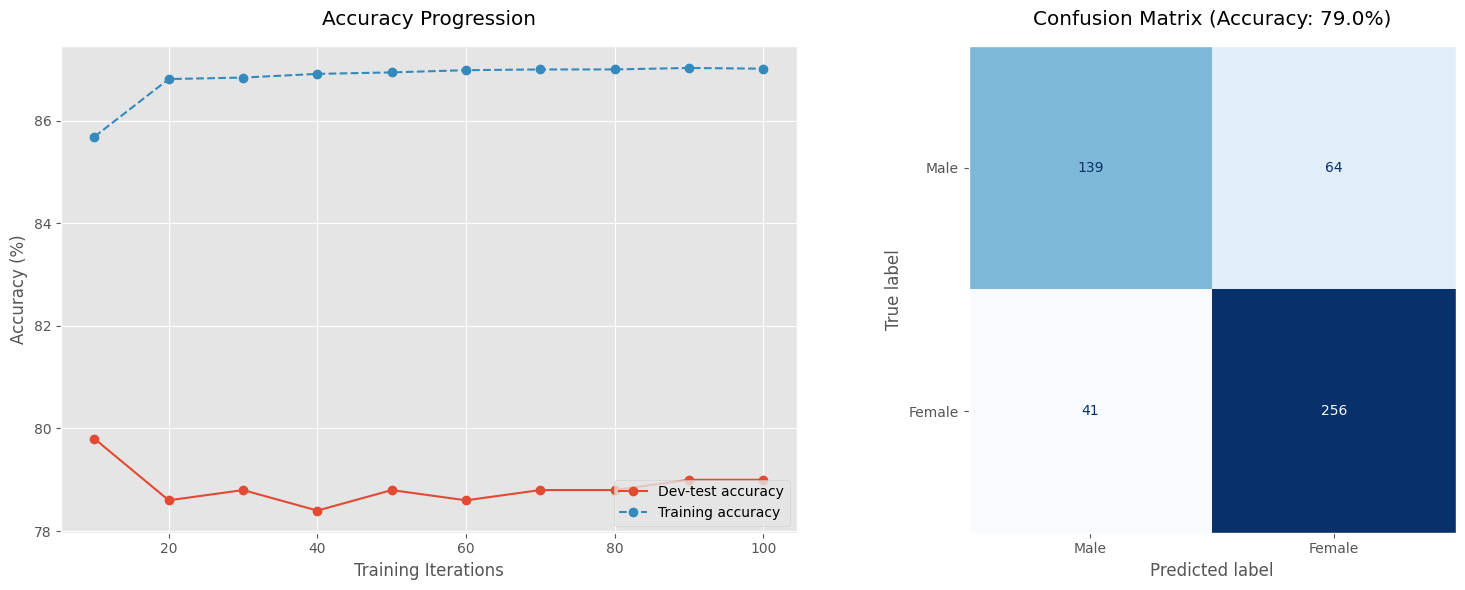

In [5]:
# Import Libraries
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

# Initialize grid
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PANEL 1 (LEFT): Accuracy Progression

# Extract data
iterations = training_history['iterations']
train_acc = training_history['train_acc']
dev_acc = training_history['dev_acc']

# Plot lines
ax1.plot(iterations, dev_acc, marker='o', label='Dev-test accuracy')
ax1.plot(iterations, train_acc, marker='o', linestyle='--', label='Training accuracy')

ax1.set_title('Accuracy Progression', pad=15)
ax1.set_xlabel('Training Iterations')
ax1.set_ylabel('Accuracy (%)')
ax1.legend(loc='lower right')

# PANEL 2 (RIGHT): Confusion Matrix

# Generate predictions
actual_labels = [label for (features, label) in devtest_features]
predicted_labels = [maxent_classifier.classify(features) for (features, label) in devtest_features]

# Construct confusion matrix array
cm = np.zeros((2, 2), dtype=int)
classes = ['male', 'female']

for true_tag, pred_tag in zip(actual_labels, predicted_labels):
    true_idx = classes.index(true_tag)
    pred_idx = classes.index(pred_tag)
    cm[true_idx, pred_idx] += 1

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Male', 'Female'])
disp.plot(ax=ax2, cmap='Blues', colorbar=False)

# Format Confusion Matrix
current_accuracy = np.trace(cm) / np.sum(cm)
ax2.set_title(f'Confusion Matrix (Accuracy: {current_accuracy*100:.1f}%)', pad=15)
ax2.grid(False) # Turn off the ggplot grid specifically for the matrix image

# Finalize Layout
plt.tight_layout()
plt.show()

##  Evaluation on the Test Set

The final evaluation on the isolated test set yields an overall accuracy of **80.80%**.

The classifier demonstrates high sensitivity for the female class, achieving an **88.29% recall** and a strong **F1-Score of 0.8532**.  However, the male metrics highlight the persistence of a structural class imbalance

Specifically, the model struggles to identify the male class, evidenced by a significantly lower **recall of 67.93%** and a lower  **F1-Score of 0.7225.**

The asymmetric performance confirms that the underlying features remain disproportionately biased toward female gender markers causing the Maximum Entropy model to **default to false-positive female predictions** when evaluating structurally ambiguous male names.

In [6]:
# Test Set Evaluation with Class Comparison
import nltk

# Evaluate Overall Accuracy
test_accuracy = nltk.classify.accuracy(maxent_classifier, test_features)
print(f"Final Test Set Accuracy: {test_accuracy:.4f}\n")

# Generate Predictions
predicted_labels = [maxent_classifier.classify(features) for (features, label) in test_features]
actual_labels = [label for (features, label) in test_features]

# Female Class Metrics
tp_female = sum(1 for p, a in zip(predicted_labels, actual_labels) if p == 'female' and a == 'female')
fp_female = sum(1 for p, a in zip(predicted_labels, actual_labels) if p == 'female' and a == 'male')
fn_female = sum(1 for p, a in zip(predicted_labels, actual_labels) if p == 'male' and a == 'female')

precision_female = tp_female / (tp_female + fp_female) if (tp_female + fp_female) > 0 else 0
recall_female = tp_female / (tp_female + fn_female) if (tp_female + fn_female) > 0 else 0
f1_female = 2 * (precision_female * recall_female) / (precision_female + recall_female) if (precision_female + recall_female) > 0 else 0

# Male Class Metrics
tp_male = sum(1 for p, a in zip(predicted_labels, actual_labels) if p == 'male' and a == 'male')
fp_male = sum(1 for p, a in zip(predicted_labels, actual_labels) if p == 'male' and a == 'female')
fn_male = sum(1 for p, a in zip(predicted_labels, actual_labels) if p == 'female' and a == 'male')

precision_male = tp_male / (tp_male + fp_male) if (tp_male + fp_male) > 0 else 0
recall_male = tp_male / (tp_male + fn_male) if (tp_male + fn_male) > 0 else 0
f1_male = 2 * (precision_male * recall_male) / (precision_male + recall_male) if (precision_male + recall_male) > 0 else 0

 # Formatted Output Table
print("-" * 45)
print(f"{'Metric':<15} | {'Female Class':<12} | {'Male Class':<12}")
print("-" * 45)
print(f"{'Precision':<15} | {precision_female:<12.4f} | {precision_male:<12.4f}")
print(f"{'Recall':<15} | {recall_female:<12.4f} | {recall_male:<12.4f}")
print(f"{'F1-Score':<15} | {f1_female:<12.4f} | {f1_male:<12.4f}")
print("-" * 45)

Final Test Set Accuracy: 0.8080

---------------------------------------------
Metric          | Female Class | Male Class  
---------------------------------------------
Precision       | 0.8254       | 0.7716      
Recall          | 0.8829       | 0.6793      
F1-Score        | 0.8532       | 0.7225      
---------------------------------------------
